## 1. Motivation

Public toilets are something people use every day, but their accessibility is not always guaranteed. For people with disabilities, finding an accessible toilet can be difficult and stressful.

In this project, we want to understand how accessible public toilets are in different Danish municipalities. By looking at the data, we can see whether access is equal for everyone or if there are differences between areas.

The goal is to raise awareness about accessibility and show how data can help identify potential problems in urban infrastructure.

### What is your dataset?

The dataset is a combination of public toilet data from two main sources:

- FindToilet, which provides information about toilets in several Danish municipalities
- OpenDataDK, which provides official data for toilets in Copenhagen

The final dataset includes:
- The location of each toilet (latitude and longitude)
- Whether the toilet is accessible or not
- The municipality where it is located
- Some additional features like water, payment, and changing tables

All datasets were combined into one single dataset to make analysis easier.

### Why did you choose this dataset?

We chose these datasets because they allow us to study accessibility in a real-world context.

FindToilet gives us data from multiple municipalities, while OpenDataDK provides more detailed and official data for Copenhagen. By combining them, we get a broader view of accessibility.

Another reason is that this topic has a clear social impact. Accessibility matters for fairness and equality, and data can help show where improvements are needed.

### What was your goal for the end user's experience?

The goal was to make the data easy to understand for everyone, even people without a technical background.

We want users to:
- Explore where public toilets are located
- See which ones are accessible
- Compare different municipalities

The idea is to present the data in a simple and visual way, so users can quickly understand the situation and form their own opinions.

## 2. Data loading and preparation

In [17]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import math
import plotly.express as px
import folium
import seaborn as sns
import requests
import geopandas as gpd
import re

In [18]:
# List of FindToilet CSV files, one per municipality
findtoilet_files = [
    "Vallensbæk.csv",
    "Dragør.csv",
    "Hillerød.csv",
    "Gentofte.csv",
    "Frederiksberg.csv",
    "Lyngby-Taarbæk.csv",
    "Bornholm.csv",
    "Helsingør.csv",
    "København.csv"
]

# Empty list to store cleaned datasets
findtoilet_dfs = []

# Load and clean each FindToilet file
for file in findtoilet_files:
    df = pd.read_csv(file)
    
    # Extract municipality name from filename
    municipality = file.replace(".csv", "")
    
    # Create a standardized dataset
    df_clean = pd.DataFrame({
        "id": df["nid"],
        "name": df["Street"],
        "city": df["City"],
        "postalcode": df["Postalcode"],
        "lat": df["Latitude"],
        "lon": df["Longitude"],
        "type": df["type"],
        
        # Mark Handicap and ChangingPlace toilets as accessible
        "accessible": df["type"].isin(["Handicap", "ChangingPlace"]).astype(int),
        
        "payment": df["Betaling"],
        "changing_table": df["Puslebord"],
        "water": df["Vandhane"],
        "description": df["Body"],
        "municipality": municipality,
        "source": "FindToilet"
    })
    
    findtoilet_dfs.append(df_clean)

# Combine all FindToilet files into one dataset
findtoilet = pd.concat(findtoilet_dfs, ignore_index=True)

findtoilet.head()

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1071,Egholmvej 19,Vallensbæk Strand,2665,55.620933,12.389692,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
1,1070,Horsbred 197,Vallensbæk,2625,55.650566,12.359040,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
2,1074,Højrupgårdsvej 1,Vallensbæk,2625,55.635456,12.367175,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
3,1067,idræts alle 2,Vallensbæk,2625,55.629609,12.372302,Handicap,1,Nej,Ja,Ja,NaN,Vallensbæk,FindToilet
4,1072,Idræts alle 5,Vallensbæk,2625,55.632575,12.369790,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet


In [19]:
# Load Copenhagen datasets from OpenDataDK
tmf = pd.read_csv("toilet_puma_agg_tmf_kk.csv")
andre = pd.read_csv("toilet_puma_agg_andre_kk.csv")

# Add source labels
tmf["source"] = "OpenDataDK_TMF"
andre["source"] = "OpenDataDK_Other"

# Combine Copenhagen datasets
cph_raw = pd.concat([tmf, andre], ignore_index=True)

# Create a standardized Copenhagen dataset
cph = pd.DataFrame({
    "id": cph_raw["id"],
    "name": cph_raw["toilet_lokalitet"],
    "city": "København",
    "postalcode": cph_raw["postnummer"],
    "lat": cph_raw["latitude"],
    "lon": cph_raw["longitude"],
    "type": cph_raw["toilet_betegnelse"],
    "accessible": cph_raw["handicapadgang"].map({"Ja": 1, "Nej": 0}),
    "payment": None,
    "changing_table": None,
    "water": None,
    "description": cph_raw["vejnavn_husnummer"],
    "municipality": "København",
    "source": cph_raw["source"]
})

cph.head()

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1,Ved Hvidtfeldtmonumentet,København,2100 København Ø,55.690343,12.599318,Toilet med handicapadgang,1,None,None,None,Langelinie 25,København,OpenDataDK_TMF
1,2,Ved Svend Vonveds Vej,København,2300 København S,55.651250,12.640587,Toilet med handicapadgang,1,None,None,None,Amager Strandvej 219,København,OpenDataDK_TMF
2,3,Kastrup Fort,København,2300 København S,55.648883,12.638843,Toilet med handicapadgang,1,None,None,None,Amager Strandvej 244,København,OpenDataDK_TMF
3,4,Amager Strandpark,København,2300 København S,55.661956,12.632448,Toilet,0,None,None,None,Amager Strandvej 55,København,OpenDataDK_TMF
4,5,Amagertorv,København,1160 København K,55.678817,12.579352,Toilet med personale,0,None,None,None,Amagertorv 1F,København,OpenDataDK_TMF


In [20]:
# Combine FindToilet and OpenDataDK datasets
toilets = pd.concat([findtoilet, cph], ignore_index=True)

toilets.head()

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1071,Egholmvej 19,Vallensbæk Strand,2665,55.620933,12.389692,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
1,1070,Horsbred 197,Vallensbæk,2625,55.650566,12.359040,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
2,1074,Højrupgårdsvej 1,Vallensbæk,2625,55.635456,12.367175,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
3,1067,idræts alle 2,Vallensbæk,2625,55.629609,12.372302,Handicap,1,Nej,Ja,Ja,NaN,Vallensbæk,FindToilet
4,1072,Idræts alle 5,Vallensbæk,2625,55.632575,12.369790,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet


### Data cleaning and preprocessing

To prepare the data for analysis, several cleaning steps were applied:

- **Merging datasets**: Data from different sources were combined into a single dataset
- **Standardizing columns**: Column names and formats were aligned across all datasets
- **Handling missing values**:
  - Missing values for features like payment, water, and changing tables were replaced with "Unknown"
  - Missing accessibility values were set to 0 (not accessible)
- **Converting data types**:
  - Coordinates were converted to numeric values
  - Accessibility was converted into a binary variable (1 = accessible, 0 = not accessible)
- **Removing duplicates**: Duplicate entries were removed based on ID and location
- **Cleaning text fields**: Names of cities and municipalities were standardized

These steps ensured that the dataset is consistent, complete, and ready for analysis and visualization.

In [21]:
# Convert coordinates to numeric values
toilets["lat"] = pd.to_numeric(toilets["lat"], errors="coerce")
toilets["lon"] = pd.to_numeric(toilets["lon"], errors="coerce")

# Convert accessibility to numeric values
toilets["accessible"] = pd.to_numeric(toilets["accessible"], errors="coerce")

# Remove rows without valid coordinates
toilets = toilets.dropna(subset=["lat", "lon"])

# Replace missing accessibility values with 0
toilets["accessible"] = toilets["accessible"].fillna(0).astype(int)

# Remove duplicated toilets
toilets = toilets.drop_duplicates(subset=["id", "lat", "lon"])


# Fill missing values for optional features
toilets["payment"] = toilets["payment"].fillna("Unknown")
toilets["changing_table"] = toilets["changing_table"].fillna("Unknown")
toilets["water"] = toilets["water"].fillna("Unknown")

# Clean postal codes
toilets["postalcode"] = pd.to_numeric(toilets["postalcode"], errors="coerce")

# Clean description
toilets["description"] = toilets["description"].fillna("")

# Clean text fields
toilets["municipality"] = toilets["municipality"].astype(str).str.strip()
toilets["city"] = toilets["city"].astype(str).str.strip()
toilets["name"] = toilets["name"].astype(str).str.strip()


columns_to_keep = [
    "id",
    "name",
    "city",
    "postalcode",
    "lat",
    "lon",
    "type",
    "accessible",
    "payment",
    "changing_table",
    "water",
    "description",
    "municipality",
    "source"
]

toilets = toilets[columns_to_keep]

# Reset index
toilets = toilets.reset_index(drop=True)

toilets.head()

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1071,Egholmvej 19,Vallensbæk Strand,2665.0,55.620933,12.389692,Handicap,1,Nej,Nej,Ja,,Vallensbæk,FindToilet
1,1070,Horsbred 197,Vallensbæk,2625.0,55.650566,12.359040,Handicap,1,Nej,Nej,Ja,,Vallensbæk,FindToilet
2,1074,Højrupgårdsvej 1,Vallensbæk,2625.0,55.635456,12.367175,Handicap,1,Nej,Nej,Ja,,Vallensbæk,FindToilet
3,1067,idræts alle 2,Vallensbæk,2625.0,55.629609,12.372302,Handicap,1,Nej,Ja,Ja,,Vallensbæk,FindToilet
4,1072,Idræts alle 5,Vallensbæk,2625.0,55.632575,12.369790,Handicap,1,Nej,Nej,Ja,,Vallensbæk,FindToilet


In [22]:
# Check final dataset size and structure
print("Number of rows:", len(toilets))
print("Number of columns:", len(toilets.columns))
print("Number of municipalities:", toilets["municipality"].nunique())

toilets.info()

Number of rows: 620
Number of columns: 14
Number of municipalities: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              620 non-null    int64  
 1   name            620 non-null    object 
 2   city            620 non-null    object 
 3   postalcode      365 non-null    float64
 4   lat             620 non-null    float64
 5   lon             620 non-null    float64
 6   type            620 non-null    object 
 7   accessible      620 non-null    int64  
 8   payment         620 non-null    object 
 9   changing_table  620 non-null    object 
 10  water           620 non-null    object 
 11  description     620 non-null    object 
 12  municipality    620 non-null    object 
 13  source          620 non-null    object 
dtypes: float64(3), int64(2), object(9)
memory usage: 67.9+ KB


In [23]:
# Export clean dataset as CSV for analysis
toilets.to_csv("clean_toilets_dataset.csv", index=False)

# Export clean dataset as JSON for website use
toilets.to_json("clean_toilets_dataset.json", orient="records", force_ascii=False)

print("Clean CSV and JSON exported successfully.")

Clean CSV and JSON exported successfully.


In [24]:
# Create GeoJSON structure for interactive maps
geojson = {
    "type": "FeatureCollection",
    "features": []
}

# Convert each toilet into a GeoJSON feature
for _, row in toilets.iterrows():
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["lon"], row["lat"]]
        },
        "properties": {
            "id": row["id"],
            "name": row["name"],
            "city": row["city"],
            "postalcode": row["postalcode"],
            "type": row["type"],
            "accessible": row["accessible"],
            "payment": row["payment"],
            "changing_table": row["changing_table"],
            "water": row["water"],
            "description": row["description"],
            "municipality": row["municipality"],
            "source": row["source"]
        }
    }
    
    geojson["features"].append(feature)

# Save GeoJSON file
with open("toilets.geojson", "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

print("GeoJSON exported successfully.")

GeoJSON exported successfully.


### Basic statistics

Before starting the analysis, we explored the dataset to better understand its structure and content.

The final dataset contains:
- 620 public toilets
- 9 municipalities
- Data from multiple sources (FindToilet and OpenDataDK)

Some first observations:
- More than half of the toilets (around 54%) are marked as accessible
- Copenhagen contains the largest number of toilets in the dataset
- Smaller municipalities tend to have fewer toilets but sometimes higher accessibility rates

These basic statistics give an initial overview and help identify patterns and imbalances in the data.

In [25]:
print(len(toilets))
print(toilets["municipality"].nunique())
print(toilets["accessible"].mean())

620
9
0.5403225806451613


### Exploratory data analysis

To better understand the dataset, we performed a simple exploratory analysis.

We looked at:
- The number of toilets per municipality
- The share of accessible toilets in each municipality

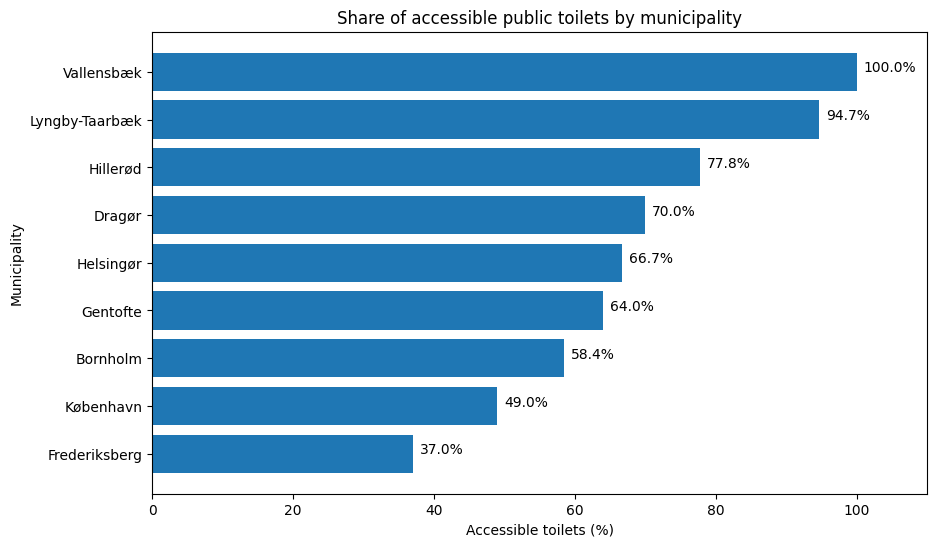

In [26]:
access_by_municipality = (
    toilets.groupby("municipality")
    .agg(
        total_toilets=("id", "count"),
        accessible_toilets=("accessible", "sum"),
        accessibility_rate=("accessible", "mean")
    )
    .reset_index()
)
import matplotlib.pyplot as plt

# Convert to percentage
access_by_municipality["accessibility_rate_percent"] = (
    access_by_municipality["accessibility_rate"] * 100
)

# Sort values for better visualization
plot_df = access_by_municipality.sort_values("accessibility_rate_percent")

# Create plot
plt.figure(figsize=(10, 6))
plt.barh(plot_df["municipality"], plot_df["accessibility_rate_percent"])

# Labels and title
plt.xlabel("Accessible toilets (%)")
plt.ylabel("Municipality")
plt.title("Share of accessible public toilets by municipality")

# Add value labels
for i, v in enumerate(plot_df["accessibility_rate_percent"]):
    plt.text(v + 1, i, f"{v:.1f}%")

plt.xlim(0, 110)

plt.show()

<span style="background-color: #fff3cd; padding: 3px; border-radius: 4px; color: black;">
This visualization is part of the exploratory data analysis (EDA) and is used to identify initial patterns.
</span>

These results show that accessibility is uneven across municipalities.

While some areas have a high percentage of accessible toilets, they often have very few facilities overall. In contrast, larger cities like Copenhagen offer more toilets, but a lower share of them are accessible.

This suggests that both availability and accessibility need to be considered when evaluating urban infrastructure. This aspect will be explored further in the following analysis.

It is also important to note that the data comes from different sources, which may affect comparability between municipalities.

To further explore the relationship between availability and accessibility, we compare the total number of toilets with the number of accessible ones:

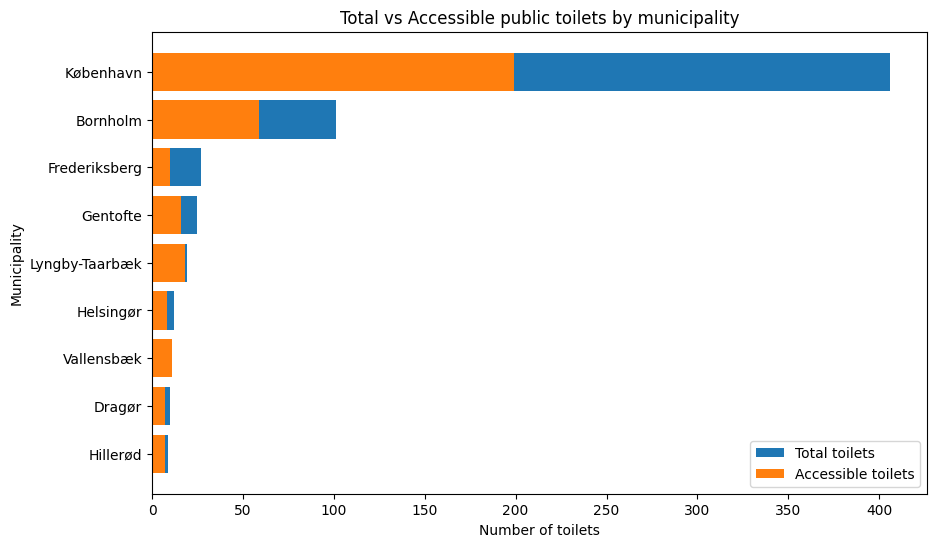

In [27]:
# Sort by total toilets
plot_df = access_by_municipality.sort_values("total_toilets")

plt.figure(figsize=(10, 6))

# Total toilets
plt.barh(plot_df["municipality"], plot_df["total_toilets"], label="Total toilets")

# Accessible toilets (encima)
plt.barh(plot_df["municipality"], plot_df["accessible_toilets"], label="Accessible toilets")

plt.xlabel("Number of toilets")
plt.ylabel("Municipality")
plt.title("Total vs Accessible public toilets by municipality")

plt.legend()

plt.show()

This visualization compares the total number of public toilets with the number of accessible toilets across municipalities.

The results highlight clear differences in both availability and accessibility. Copenhagen has by far the highest number of toilets, and also the highest number of accessible ones in absolute terms. However, a large gap remains between total and accessible facilities.

In contrast, smaller municipalities such as Vallensbæk, Dragør, and Hillerød have very few toilets overall. Even if a relatively large share of them is accessible, the total number of accessible toilets remains low.

This reinforces an important point: a high accessibility rate does not necessarily mean good accessibility in practice. In areas with few facilities, even a high percentage can still result in limited real access.

## 3. Spatial and Additional Data Preparation

### 3.1 Load cleaned toilets dataset

In [28]:
df = pd.read_csv ("clean_toilets_dataset.csv")

display(df.head())

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1071,Egholmvej 19,Vallensbæk Strand,2665.0,55.620933,12.389692,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
1,1070,Horsbred 197,Vallensbæk,2625.0,55.650566,12.359040,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
2,1074,Højrupgårdsvej 1,Vallensbæk,2625.0,55.635456,12.367175,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
3,1067,idræts alle 2,Vallensbæk,2625.0,55.629609,12.372302,Handicap,1,Nej,Ja,Ja,NaN,Vallensbæk,FindToilet
4,1072,Idræts alle 5,Vallensbæk,2625.0,55.632575,12.369790,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet


### 3.2 Load population data

In [29]:
pop_df = pd.read_excel("population_density.xlsx")

pop_df.head()

,Municipality,Population,Area (km^2),Population density/(km^2),Total number of toilets,Per Capita toilets,Per square km toilets
0,Copenhagen,671714,90.9,7389.592959,406,0.060442,4.466447
1,Frederiksberg,106150,8.7,12201.149425,27,0.025436,3.103448
2,Dragør,14474,18.3,790.928962,10,0.069089,0.546448
3,Gentofte,75106,25.6,2933.828125,25,0.033286,0.976562
4,Lyngby-Taarbæk,58614,38.8,1510.670103,19,0.032415,0.489691


### 3.3 Load municipality boundaries

In [30]:
# Working GeoJSON source
url = "https://raw.githubusercontent.com/magnuslarsen/geoJSON-Danish-municipalities/master/municipalities/municipalities.geojson"

# Download locally
r = requests.get(url)

print(r.status_code)

with open("municipalities.geojson", "wb") as f:
    f.write(r.content)

print("File downloaded")

# Load file
gdf = gpd.read_file("municipalities.geojson")

print(gdf.columns)

gdf.head()

200
File downloaded
Index(['lau_1', 'label_en', 'label_dk', 'iso_3166_2', 'geometry'], dtype='object')


,lau_1,label_en,label_dk,iso_3166_2,geometry
0,766,Hedensted,Hedensted,DK-82,"POLYGON Z ((9.44919 55.86046 -999, 9.4602 55.8..."
1,766,Hedensted,Hedensted,DK-82,"POLYGON Z ((10.06198 55.83301 -999, 10.06243 5..."
2,561,Esbjerg,Esbjerg,DK-83,"POLYGON Z ((8.59656 55.53506 -999, 8.60144 55...."
3,849,Jammerbugt,Jammerbugt,DK-81,"POLYGON Z ((9.78314 57.07319 -999, 9.78172 57...."
4,849,Jammerbugt,Jammerbugt,DK-81,"POLYGON Z ((9.19738 57.13868 -999, 9.20749 57...."


Create the boundries for selected municipalities

In [31]:
municipalities = [
    'Vallensbæk',
    'Dragør',
    'Hillerød',
    'Gentofte',
    'Frederiksberg',
    'Lyngby-Taarbæk',
    'Bornholm',
    'Helsingør',
    'København'
]

filtered = gdf[gdf["label_dk"].isin(municipalities)]

filtered.to_file(
    "selected_municipalities.geojson",
    driver="GeoJSON"
)

<Axes: >

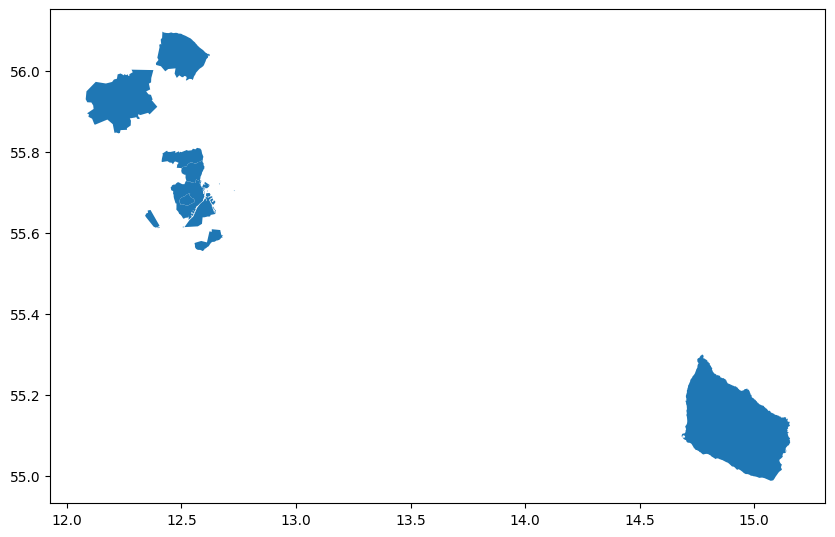

In [32]:
filtered.plot(figsize=(10, 10))

### 3.4 Validate geospatial data

Since, all the other data is cleaned previously only the geo data validity is tested here

In [33]:
gdf1 = gpd.read_file("selected_municipalities.geojson")

In [34]:
from shapely.geometry import Point

# convert toilets to GeoDataFrame
geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
toilets_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# spatial join
joined = gpd.sjoin(toilets_gdf, gdf1, how="left", predicate="within")

print(joined["index_right"].isna().sum())

15


15 Data points are outside from the boundaries that we have defined. LEt's check the municipalties that these points are belong

In [35]:
outside = joined[joined["index_right"].isna()]

outside[[
    "name", "municipality", "city", "lat", "lon", "source"
]]

,name,municipality,city,lat,lon,source
248,Havkajakvej 14,København,København S,55.648422,12.647289,FindToilet
256,Kalvebod Brygge 3C,København,København V,55.669141,12.575980,FindToilet
286,Sandkaj 37,København,Nordhavn,55.706277,12.597487,FindToilet
320,Ben Websters Vej 69,København,København SV,55.646499,12.554031,FindToilet
325,Damhusdæmningen 14,København,Vanløse,55.682449,12.468016,FindToilet
345,Langeliniekaj 63,København,København Ø,55.703656,12.600802,FindToilet
388,Kalvebod Bølge,København,København,55.667831,12.573395,OpenDataDK_TMF
400,Havnebadet Sluseholmen,København,København,55.646462,12.553980,OpenDataDK_TMF
444,Det Flydende Aktivitetshus,København,København,55.706279,12.597424,OpenDataDK_TMF
517,Strandstation 5,København,København,55.648439,12.647273,OpenDataDK_TMF


Since all the outside points are belong to Copenhagen municipalty, we have increased the boundries by 100 m to observe whether they belong to boundries

In [36]:
gdf_buffered = gdf.to_crs(epsg=25832)   # Danish projected CRS
gdf_buffered["geometry"] = gdf_buffered.geometry.buffer(100)  # 100 meters buffer
gdf_buffered = gdf_buffered.to_crs(epsg=4326)

joined_buffered = gpd.sjoin(
    toilets_gdf,
    gdf_buffered,
    how="left",
    predicate="within"
)

print("Outside after 100m buffer:", joined_buffered["index_right"].isna().sum())

Outside after 100m buffer: 0


After increasing boundries no outside points are available; which means all of these points locate near the boundries, harbour or similar places. This is just for validity check, but we do not change the boundries in the analysis

## 4. Data Analysis

### 4.1 Population density vs per capita toilets

This analysis explores the relationship between population density and toilet availability across municipalities.

In [37]:
pop_df["Municipality"] = pop_df["Municipality"].str.strip()
gdf1["label_dk"] = gdf1["label_dk"].str.strip()

pop_df.columns = pop_df.columns.str.strip()

# Rename messy columns
pop_df = pop_df.rename(columns={
    "Municipalty": "Municipality",
    "Population density/(km^2)": "Population density",
    "Total number of toilets": "Total toilets",
    "Per Capita toilets": "Per capita toilets",
    "Per square km toilets": "Per square km toilets"
})

# Clean values
pop_df["Municipality"] = pop_df["Municipality"].astype(str).str.strip()

pop_df["Per capita toilets"] = (
    pop_df["Per capita toilets"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

pop_df["Population density"] = pd.to_numeric(pop_df["Population density"], errors="coerce")
pop_df["Total toilets"] = pd.to_numeric(pop_df["Total toilets"], errors="coerce")

# Scatter plot
fig = px.scatter(
    pop_df,
    x="Population density",
    y="Per capita toilets",
    size="Total toilets",
    color="Municipality",
    hover_name="Municipality",
    text="Municipality",
    size_max=32,
    #title="Population Density vs Per Capita Toilet Access",
    labels={
        "Population density": "Population density (people per km²)",
        "Per capita toilets": "Per capita toilets (%)",
        "Total toilets": "Total toilets"
    },
    template="plotly_white"
)

fig.update_traces(
    textposition="top center",
    marker=dict(
        opacity=0.8,
        line=dict(width=1, color="black")
    )
)

fig.update_layout(

    height=380,

    margin=dict(
        l=40,
        r=40,
        t=20,
        b=40
    ),

    legend_title_text="Municipality",

    yaxis=dict(
        title="Per capita toilets (%)",
        automargin=True,
        range=[
            0,
            pop_df["Per capita toilets"].max() * 1.15
        ]
    )
)

import os

# Create folder 
os.makedirs("maps", exist_ok=True)

# Save interactive HTML
fig.write_html("maps/scatter_plot.html")
#fig.write_image("plots/scatter_plot.png")
fig.show()

The analysis reveals noticeable differences between municipalities in terms of toilet availability relative to population density.

Frederiksberg has one of the highest population densities but relatively low toilet availability per capita. In contrast, municipalities such as Dragør and Vallensbæk show lower population density and comparatively higher toilet availability per resident.

Copenhagen stands out because it combines high population density with a very large number of toilets overall. However, when considering population size, the availability per resident remains more moderate than expected.

These results suggest that population density alone does not determine accessibility. Urban structure, tourism, transportation hubs, and regional planning may also influence the distribution of public toilet infrastructure.

### 4.2 Spatial distribution of toilets

Accessibility is also influenced by the spatial distribution of facilities. To better understand geographic accessibility patterns, we visualize the location of toilets across municipalities and compare accessible and non-accessible facilities spatially.

In [38]:
# Clean data
map_df = df.dropna(subset=["lat", "lon"]).copy()

# Convert accessibility safely
map_df["accessible"] = (
    pd.to_numeric(map_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# CREATE MAP

overview_map = folium.Map(
    location=[55.68, 12.57],
    zoom_start=9,
    tiles="OpenStreetMap"
)

# ADD TOILET POINTS

for _, row in map_df.iterrows():

    color = "green" if row["accessible"] == 1 else "red"

    popup_text = f"""
    <b>{row.get('name', 'Unknown')}</b><br>
    Municipality: {row.get('municipality', 'Unknown')}<br>
    City: {row.get('city', 'Unknown')}<br>
    Type: {row.get('type', 'Unknown')}
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        weight=1,
        popup=popup_text
    ).add_to(overview_map)

# DISPLAY

overview_map

The spatial visualization reveals that public toilets are not evenly distributed across municipalities.

Most toilets are concentrated around urban centers, transportation hubs, tourist areas, and coastal regions. Copenhagen shows the highest concentration of facilities, while smaller municipalities display more dispersed spatial patterns.

The map also highlights visible differences between accessible and non-accessible toilets. In some municipalities, accessible toilets appear clustered in central areas, potentially limiting accessibility in peripheral zones.

These spatial patterns suggest that geographic accessibility depends not only on the number of facilities, but also on where they are located within urban space.

### 4.3 Municipality accessibility animation

This animated visualization was created to explore accessibility patterns municipality by municipality.

Because the selected municipalities are geographically dispersed and vary significantly in size, a single static map makes detailed comparison difficult. The animation isolates each municipality individually and automatically adjusts the zoom level to improve spatial understanding.

In [39]:
from branca.element import MacroElement
from jinja2 import Template


# CLEAN TOILET DATA

map_df = df.dropna(subset=["lat", "lon", "municipality"]).copy()
map_df["municipality"] = map_df["municipality"].str.strip()

map_df["accessible"] = (
    pd.to_numeric(map_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# LOAD MUNICIPALITY BOUNDARIES
muni_gdf = gpd.read_file("selected_municipalities.geojson")
muni_gdf = muni_gdf.to_crs(epsg=4326)
muni_gdf["label_dk"] = muni_gdf["label_dk"].str.strip()

# Fix invalid geometries
muni_gdf["geometry"] = muni_gdf.geometry.buffer(0)

# MUNICIPALITIES TO ANIMATE
municipalities = [
    "Vallensbæk",
    "Dragør",
    "Hillerød",
    "Gentofte",
    "Frederiksberg",
    "Lyngby-Taarbæk",
    "Helsingør",
    "København",
    "Bornholm"
]

map_df = map_df[map_df["municipality"].isin(municipalities)].copy()
muni_gdf = muni_gdf[muni_gdf["label_dk"].isin(municipalities)].copy()

available_munis = sorted(
    set(map_df["municipality"].unique()) &
    set(muni_gdf["label_dk"].unique())
)

municipalities = [m for m in municipalities if m in available_munis]

print("Municipalities used:", municipalities)

# CONVERT DATA TO JSON
def safe_str(x):
    if pd.isna(x):
        return "Unknown"
    return str(x)

records = []

for _, row in map_df.iterrows():
    records.append({
        "municipality": safe_str(row["municipality"]),
        "lat": float(row["lat"]),
        "lon": float(row["lon"]),
        "name": safe_str(row.get("name")),
        "city": safe_str(row.get("city")),
        "type": safe_str(row.get("type")),
        "accessible": int(row["accessible"])
    })

municipality_geojson = json.loads(muni_gdf.to_json())

# CREATE MAP
m = folium.Map(
    location=[55.75, 12.45],
    zoom_start=9,
    tiles="CartoDB positron"
)


# ANIMATION CLASS
class MunicipalityAnimation(MacroElement):

    def __init__(self, records, municipalities, municipality_geojson):
        super().__init__()

        self._name = "MunicipalityAnimation"
        self.records = json.dumps(records)
        self.municipalities = json.dumps(municipalities)
        self.municipality_geojson = json.dumps(municipality_geojson)

        self._template = Template("""
        {% macro html(this, kwargs) %}

        <div id="municipality-box" style="
            position: fixed;
            top: 100px;
            left: 20px;
            width: 220px;
            background-color: white;
            border: 2px solid #555;
            z-index: 9999;
            font-size: 15px;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.25);
        ">

            <b style="font-size:18px;">Municipality</b><br>
            <span id="municipality-name" style="font-size:17px;">Loading...</span>

            <br><br>

            Total toilets: <span id="total-count">0</span><br>
            <span style="color:blue;">●</span> Accessible:
            <span id="accessible-count">0</span><br>
            <span style="color:red;">●</span> Not accessible:
            <span id="not-accessible-count">0</span>

            <br><br>

            <button id="prev-btn">Previous</button>
            <button id="play-btn">Pause</button>
            <button id="next-btn">Next</button>

            <br><br>

            <small>
                <span style="color:#003f8c;">━</span> Current municipality<br>
                <span style="color:#999;">━</span> Other municipalities
            </small>

        </div>

        {% endmacro %}

        {% macro script(this, kwargs) %}

        var toiletData = {{ this.records }};
        var municipalities = {{ this.municipalities }};
        var geojsonData = {{ this.municipality_geojson }};
        var map = {{ this._parent.get_name() }};

        var currentIndex = 0;
        var animationSpeed = 7000;
        var animationTimer = null;
        var isPlaying = true;

        var activeMarkers = [];
        var activePolygon = null;
        var backgroundPolygons = null;

        // Change to false if you want to hide other municipality boundaries completely
        var showOtherBoundaries = true;

        function clearLayers() {
            activeMarkers.forEach(function(marker) {
                map.removeLayer(marker);
            });
            activeMarkers = [];

            if (activePolygon) {
                map.removeLayer(activePolygon);
                activePolygon = null;
            }

            if (backgroundPolygons) {
                map.removeLayer(backgroundPolygons);
                backgroundPolygons = null;
            }
        }

        function showMunicipality(index) {
            clearLayers();

            var currentMuni = municipalities[index];
            document.getElementById("municipality-name").innerHTML = currentMuni;

            var total = 0;
            var accessible = 0;
            var notAccessible = 0;

            var combinedBounds = L.latLngBounds([]);

            // ---------------------------------------------------
            // LIGHT BACKGROUND BOUNDARIES
            // ---------------------------------------------------

            if (showOtherBoundaries) {
                backgroundPolygons = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk !== currentMuni;
                    },
                    style: {
                        color: "#999999",
                        weight: 1,
                        fillColor: "#dddddd",
                        fillOpacity: 0.05,
                        opacity: 0.35
                    },
                    interactive: false
                }).addTo(map);
            }

            // ---------------------------------------------------
            // ACTIVE MUNICIPALITY BOUNDARY
            // ---------------------------------------------------

            activePolygon = L.geoJSON(geojsonData, {
                filter: function(feature) {
                    return feature.properties.label_dk === currentMuni;
                },
                style: {
                    color: "#003f8c",
                    weight: 4,
                    fillColor: "#4a90e2",
                    fillOpacity: 0.12,
                    opacity: 1
                }
            }).addTo(map);

            if (activePolygon.getBounds().isValid()) {
                combinedBounds.extend(activePolygon.getBounds());
            }

            // ---------------------------------------------------
            // TOILET POINTS
            // ---------------------------------------------------

            toiletData.forEach(function(row) {
                if (row.municipality === currentMuni) {

                    total += 1;

                    var color = row.accessible === 1 ? "blue" : "red";
                    var accessText = row.accessible === 1 ? "Accessible" : "Not accessible";

                    if (row.accessible === 1) {
                        accessible += 1;
                    } else {
                        notAccessible += 1;
                    }

                    var popupText =
                        "<b>" + row.name + "</b><br>" +
                        "Municipality: " + row.municipality + "<br>" +
                        "City: " + row.city + "<br>" +
                        "Type: " + row.type + "<br>" +
                        "Accessibility: " + accessText;

                    var marker = L.circleMarker(
                        [row.lat, row.lon],
                        {
                            radius: 4,
                            color: color,
                            fillColor: color,
                            fillOpacity: 0.75,
                            opacity: 0.9,
                            weight: 1
                        }
                    ).bindPopup(popupText);

                    marker.addTo(map);
                    activeMarkers.push(marker);

                    combinedBounds.extend([row.lat, row.lon]);
                }
            });

            document.getElementById("total-count").innerHTML = total;
            document.getElementById("accessible-count").innerHTML = accessible;
            document.getElementById("not-accessible-count").innerHTML = notAccessible;

            if (combinedBounds.isValid()) {
                map.fitBounds(combinedBounds, {
                    padding: [90, 90],
                    maxZoom: 12
                });
            }

            if (currentMuni === "København") {
                setTimeout(function() {
                    if (map.getZoom() > 11) {
                        map.setZoom(11);
                    }
                }, 300);
            }

            if (
                currentMuni === "Vallensbæk" ||
                currentMuni === "Dragør" ||
                currentMuni === "Frederiksberg"
            ) {
                setTimeout(function() {
                    if (map.getZoom() > 13) {
                        map.setZoom(13);
                    }
                }, 300);
            }

            if (currentMuni === "Bornholm") {
                setTimeout(function() {
                    if (map.getZoom() > 10) {
                        map.setZoom(10);
                    }
                }, 300);
            }
        }

        function nextMunicipality() {
            currentIndex = (currentIndex + 1) % municipalities.length;
            showMunicipality(currentIndex);
        }

        function prevMunicipality() {
            currentIndex = (currentIndex - 1 + municipalities.length) % municipalities.length;
            showMunicipality(currentIndex);
        }

        function startAnimation() {
            animationTimer = setInterval(nextMunicipality, animationSpeed);
            isPlaying = true;
            document.getElementById("play-btn").innerHTML = "Pause";
        }

        function stopAnimation() {
            clearInterval(animationTimer);
            animationTimer = null;
            isPlaying = false;
            document.getElementById("play-btn").innerHTML = "Play";
        }

        document.getElementById("play-btn").onclick = function() {
            if (isPlaying) {
                stopAnimation();
            } else {
                startAnimation();
            }
        };

        document.getElementById("next-btn").onclick = function() {
            stopAnimation();
            nextMunicipality();
        };

        document.getElementById("prev-btn").onclick = function() {
            stopAnimation();
            prevMunicipality();
        };

        showMunicipality(currentIndex);
        startAnimation();

        {% endmacro %}
        """)


# ADD TO MAP
animation = MunicipalityAnimation(
    records,
    municipalities,
    municipality_geojson
)

m.add_child(animation)

# Create folder to save maps
import os
os.makedirs("maps", exist_ok=True)

# Save map
m.save("maps/toilet_distribution_map.html")

m

Municipalities used: ['Vallensbæk', 'Dragør', 'Hillerød', 'Gentofte', 'Frederiksberg', 'Lyngby-Taarbæk', 'Helsingør', 'København', 'Bornholm']


The animation highlights important differences in accessibility and spatial organization between municipalities.

Larger municipalities such as Copenhagen contain dense clusters of toilets distributed across several urban areas, while smaller municipalities show fewer and more concentrated facilities.

The visualization also makes accessibility disparities easier to identify spatially. Some municipalities contain a relatively balanced distribution of accessible toilets, while others show stronger concentration patterns around central locations.

The animated approach improves readability by allowing users to focus on one municipality at a time instead of comparing all municipalities simultaneously on a single crowded map.

This visualization therefore supports both exploration and storytelling by guiding the user through the geographic differences between municipalities.

### 4.4 Accessibility over time

Accessibility is not only related to physical location, but also to when facilities are available.

Since opening hours are not directly structured in the dataset, they were extracted from the description field using text processing techniques. This allows us to estimate temporal accessibility patterns throughout the day.

Total toilets: 620
Toilets with detected opening hours: 157


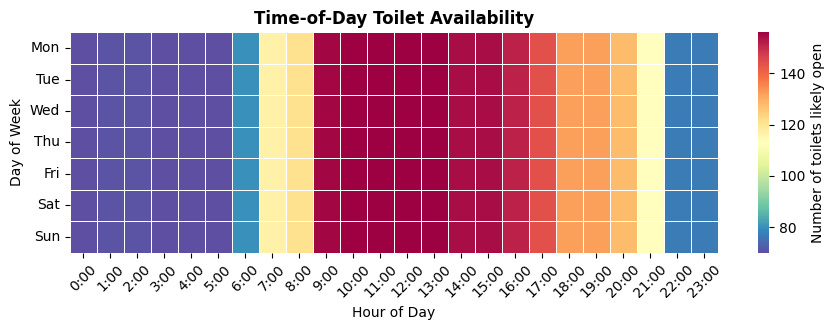

In [40]:
# COPY DATA

hours_df = df.copy()

# Use description column because opening hours are inside text
hours_df["description"] = hours_df["description"].fillna("").astype(str)

# FUNCTION: DETECT OPENING HOURS

def extract_open_hours(text):
    text = text.lower()

    # 24-hour toilets
    if (
        "døgnåbent" in text
        or "24/7" in text
        or "hele døgnet" in text
        or "doegnaabent: ja" in text
    ):
        return list(range(24))

    # Match time ranges like 7-22, 07:00-22:00, 9.00 - 21.00
    patterns = re.findall(
        r"(\d{1,2})(?:[:.]\d{2})?\s*[–\-]\s*(\d{1,2})(?:[:.]\d{2})?",
        text
    )

    open_hours = []

    for start, end in patterns:
        start = int(start)
        end = int(end)

        if 0 <= start <= 23 and 0 <= end <= 24:
            if start < end:
                open_hours.extend(range(start, end))
            else:
                # overnight case, e.g. 22-06
                open_hours.extend(list(range(start, 24)) + list(range(0, end)))

    return sorted(set(open_hours))


# APPLY FUNCTION

hours_df["open_hours"] = hours_df["description"].apply(extract_open_hours)

# Keep only rows where some opening hour could be detected
hours_df_valid = hours_df[hours_df["open_hours"].apply(len) > 0].copy()

print("Total toilets:", len(hours_df))
print("Toilets with detected opening hours:", len(hours_df_valid))


# CREATE DAY-HOUR MATRIX

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hours = list(range(24))

heat_data = pd.DataFrame(0, index=days, columns=hours)

# Assumption: if opening hours are detected, apply to all days
# unless your text is parsed in more detail later
for _, row in hours_df_valid.iterrows():
    for h in row["open_hours"]:
        for d in days:
            heat_data.loc[d, h] += 1


# PLOT HEATMAP

plt.figure(figsize=(9, 3.4))

sns.heatmap(
    heat_data,
    cmap="Spectral_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of toilets likely open"}
)

plt.title("Time-of-Day Toilet Availability", fontsize=12, weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(
    ticks=np.arange(24) + 0.5,
    labels=[f"{h}:00" for h in range(24)],
    rotation=45
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("opening hours heatmap")
plt.show()

The heatmap reveals that public toilet availability is concentrated mainly during daytime hours.

Most facilities appear to be available between morning and evening periods, while accessibility decreases significantly during nighttime and early morning hours.

This pattern suggests that temporal accessibility may be limited for users who rely on public facilities outside standard daytime activity periods, including commuters, tourists, nightlife visitors, and people traveling late at night.

It is important to note that opening hours were extracted from unstructured text descriptions, meaning the results may not be fully accurate for all facilities. However, the visualization still provides a useful overview of general temporal accessibility patterns across the dataset.

### 4.5 Facility distribution heatmap

This analysis explores the distribution of additional accessibility-related facilities across municipalities.

Beyond wheelchair accessibility, public toilets may provide other important features such as changing tables, water availability, and free access. The heatmap allows us to compare how these facilities are distributed geographically.

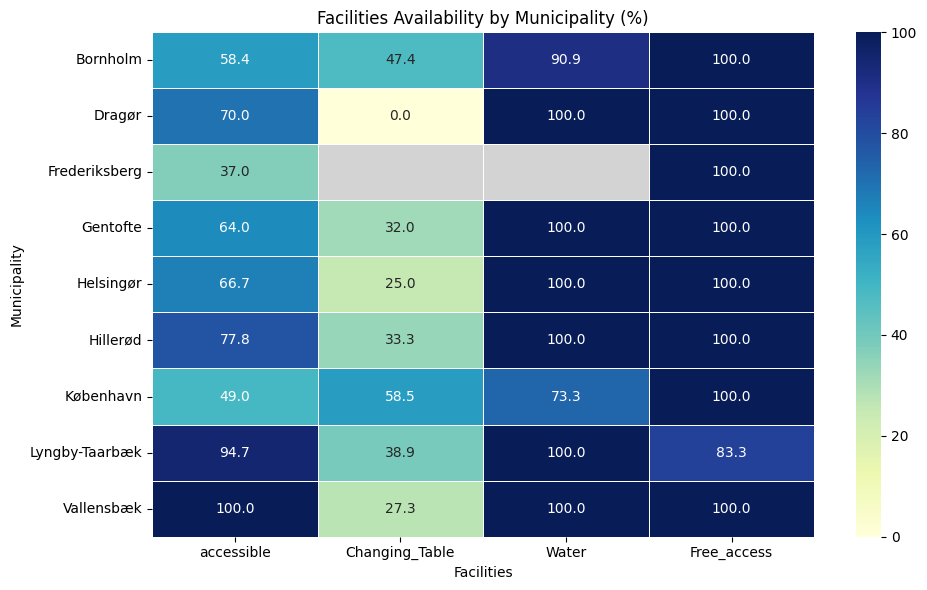

In [41]:
# Convert categorical to numeric
mapping = {
    "Ja": 1,
    "Nej": 0,
    "Unknown": None,
    "Ved ikke": None
}

df["Changing_Table"] = df["changing_table"].map(mapping)
df["Water"] = df["water"].map(mapping)

# Payment: treat "Nej" (No payment) as free
df["Free_access"] = df["payment"].map({
    "Nej": 1,
    "Ja": 0,
    "Unknown": None,
    "Ved ikke": None
})
heatmap_data = df.groupby("municipality").agg({
    "accessible": "mean",
    "Changing_Table": "mean",
    "Water": "mean",
    "Free_access": "mean"
})
heatmap_data = heatmap_data * 100
heatmap_data = heatmap_data.round(1)

# Create a copy of colormap
cmap = sns.color_palette("YlGnBu", as_cmap=True)

# Set color for NaN values (light gray)
cmap.set_bad(color="lightgrey")

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Facilities Availability by Municipality (%)")
plt.xlabel("Facilities")
plt.ylabel("Municipality")

plt.tight_layout()
plt.savefig("facility_distribution_heatmap")
plt.show()

The heatmap reveals noticeable variation in facility availability across municipalities.

Some municipalities provide a wider range of accessibility-related features, while others offer more limited facility support. Wheelchair accessibility appears more common than additional features such as changing tables or water availability.

The analysis also suggests that accessibility is multidimensional. A toilet may technically be accessible while still lacking other facilities that improve usability for different user groups.

These results highlight the importance of evaluating accessibility beyond a single binary indicator.

### 4.6 Interactive toilet finder

Different users may have different accessibility needs when searching for public toilets.

To support user-centered exploration, an interactive filtering system was developed. Users can search for toilets based on accessibility features, municipality, water availability, changing tables, and free access.

In [42]:
from branca.element import MacroElement
from jinja2 import Template


# DATA

facility_df = df.dropna(subset=["lat", "lon", "municipality"]).copy()
facility_df["municipality"] = facility_df["municipality"].astype(str).str.strip()

facility_df["accessible"] = (
    pd.to_numeric(facility_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)


# LOAD MUNICIPALITY BOUNDARIES
muni_gdf = gpd.read_file("selected_municipalities.geojson")
muni_gdf = muni_gdf.to_crs(epsg=4326)
muni_gdf["label_dk"] = muni_gdf["label_dk"].astype(str).str.strip()
muni_gdf["geometry"] = muni_gdf.geometry.buffer(0)

# Keep only municipalities that exist in toilet data
available_munis = sorted(set(facility_df["municipality"]) & set(muni_gdf["label_dk"]))
facility_df = facility_df[facility_df["municipality"].isin(available_munis)].copy()
muni_gdf = muni_gdf[muni_gdf["label_dk"].isin(available_munis)].copy()


# SAFE STRING FUNCTION

def safe_str(x):
    if pd.isna(x):
        return "Unknown"
    return str(x)


# RECORDS FOR JAVASCRIPT
records = []

for _, row in facility_df.iterrows():
    records.append({
        "municipality": safe_str(row.get("municipality")),
        "lat": float(row["lat"]),
        "lon": float(row["lon"]),
        "name": safe_str(row.get("name")),
        "city": safe_str(row.get("city")),
        "type": safe_str(row.get("type")),
        "accessible": int(row.get("accessible", 0)),
        "payment": safe_str(row.get("payment")),
        "changing_table": safe_str(row.get("changing_table")),
        "water": safe_str(row.get("water")),
        "description": safe_str(row.get("description"))
    })

records_json = json.dumps(records)
municipality_geojson = json.dumps(json.loads(muni_gdf.to_json()))


# CREATE BASE MAP
m = folium.Map(
    location=[facility_df["lat"].mean(), facility_df["lon"].mean()+1.0],
    zoom_start=8,
    tiles="OpenStreetMap"
)


# CUSTOM INTERACTIVE FILTER WITH BOUNDARIES

class FacilityFilterMap(MacroElement):

    def __init__(self, records_json, municipality_geojson):
        super().__init__()
        self._name = "FacilityFilterMap"
        self.records_json = records_json
        self.municipality_geojson = municipality_geojson

        self._template = Template("""
        {% macro html(this, kwargs) %}

        <div id="filter-panel" style="
            position: fixed;
            top: 20px;
            right: 20px;
            width: 230px;
            background-color: white;
            border: 2px solid #555;
            z-index: 9999;
            font-size: 12px;
            padding: 10px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.25);
        ">

            <b style="font-size:14px;">Find toilets by facilities</b>

            <br><br>

            <label>
                <input type="checkbox" id="filter-accessible">
                Accessible toilet
            </label><br>

            <label>
                <input type="checkbox" id="filter-changing">
                Changing table
            </label><br>

            <label>
                <input type="checkbox" id="filter-water">
                Water available
            </label><br>

            <label>
                <input type="checkbox" id="filter-free">
                Free to use
            </label><br>

            <br>

            <label><b>Municipality</b></label><br>
            <select
                id="municipality-select"
                style="
                    width:100%;
                    margin-top:4px;
                    padding:3px;
                    font-size:12px;
                "
            >
                <option value="All">All municipalities</option>
            </select>

            <br><br>

            Matching toilets:
            <b><span id="match-count">0</span></b>

            <br><br>

            <img src="https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-blue.png"
                 width="14"> Accessible<br>

            <img src="https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-red.png"
                 width="14"> Not accessible<br>
            <span style="color:#003f8c;">━</span> Selected boundary<br>
            <span style="color:#999;">━</span> Other boundaries

        </div>

        {% endmacro %}

        {% macro script(this, kwargs) %}

        var toiletData = {{ this.records_json }};
        var geojsonData = {{ this.municipality_geojson }};
        var map = {{ this._parent.get_name() }};

        var activeMarkers = [];
        var activeBoundary = null;
        var backgroundBoundaries = null;

        // ---------------------------------------------------
        // ADD MUNICIPALITIES TO DROPDOWN
        // ---------------------------------------------------

        var municipalities = [...new Set(toiletData.map(d => d.municipality))].sort();
        var select = document.getElementById("municipality-select");

        municipalities.forEach(function(muni) {
            var option = document.createElement("option");
            option.value = muni;
            option.text = muni;
            select.appendChild(option);
        });

        // ---------------------------------------------------
        // CLEAN YES/NO VALUES
        // ---------------------------------------------------

        function isYes(value) {
            if (!value) return false;
            value = value.toString().toLowerCase().trim();
            return value === "ja" || value === "yes" || value === "1" || value === "true";
        }

        function isNo(value) {
            if (!value) return false;
            value = value.toString().toLowerCase().trim();
            return value === "nej" || value === "no" || value === "0" || value === "false";
        }

        // ---------------------------------------------------
        // CLEAR LAYERS
        // ---------------------------------------------------

        function clearLayers() {
            activeMarkers.forEach(function(marker) {
                map.removeLayer(marker);
            });
            activeMarkers = [];

            if (activeBoundary) {
                map.removeLayer(activeBoundary);
                activeBoundary = null;
            }

            if (backgroundBoundaries) {
                map.removeLayer(backgroundBoundaries);
                backgroundBoundaries = null;
            }
        }

        // ---------------------------------------------------
        // ADD BOUNDARIES
        // ---------------------------------------------------

        function addBoundaries(selectedMuni, bounds) {

            if (selectedMuni === "All") {
                backgroundBoundaries = L.geoJSON(geojsonData, {
                    style: {
                        color: "#003f8c",
                        weight: 2,
                        fillColor: "#4a90e2",
                        fillOpacity: 0.06,
                        opacity: 0.85
                    },
                    tooltip: function(layer) {
                        return layer.feature.properties.label_dk;
                    }
                }).addTo(map);

                if (backgroundBoundaries.getBounds().isValid()) {
                    bounds.extend(backgroundBoundaries.getBounds());
                }

            } else {

                backgroundBoundaries = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk !== selectedMuni;
                    },
                    style: {
                        color: "#999999",
                        weight: 1,
                        fillColor: "#dddddd",
                        fillOpacity: 0.04,
                        opacity: 0.30
                    },
                    interactive: false
                }).addTo(map);

                activeBoundary = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk === selectedMuni;
                    },
                    style: {
                        color: "#003f8c",
                        weight: 4,
                        fillColor: "#4a90e2",
                        fillOpacity: 0.12,
                        opacity: 1
                    }
                }).addTo(map);

                if (activeBoundary.getBounds().isValid()) {
                    bounds.extend(activeBoundary.getBounds());
                }
            }
        }

        // ---------------------------------------------------
        // UPDATE MAP
        // ---------------------------------------------------

        function updateMap() {

            clearLayers();

            var requireAccessible = document.getElementById("filter-accessible").checked;
            var requireChanging = document.getElementById("filter-changing").checked;
            var requireWater = document.getElementById("filter-water").checked;
            var requireFree = document.getElementById("filter-free").checked;
            var selectedMuni = document.getElementById("municipality-select").value;

            var bounds = L.latLngBounds([]);

            addBoundaries(selectedMuni, bounds);

            var filtered = toiletData.filter(function(row) {

                if (selectedMuni !== "All" && row.municipality !== selectedMuni) {
                    return false;
                }

                if (requireAccessible && row.accessible !== 1) {
                    return false;
                }

                if (requireChanging && !isYes(row.changing_table)) {
                    return false;
                }

                if (requireWater && !isYes(row.water)) {
                    return false;
                }

                if (requireFree && !isNo(row.payment)) {
                    return false;
                }

                return true;
            });

            filtered.forEach(function(row) {

                var iconColor = row.accessible === 1 ? "blue" : "red";
                var accessText = row.accessible === 1 ? "Accessible" : "Not accessible";

                var popupText =
                    "<b>" + row.name + "</b><br>" +
                    "Municipality: " + row.municipality + "<br>" +
                    "City: " + row.city + "<br>" +
                    "Type: " + row.type + "<br>" +
                    "Accessibility: " + accessText + "<br>" +
                    "Changing table: " + row.changing_table + "<br>" +
                    "Water: " + row.water + "<br>" +
                    "Payment: " + row.payment;

                var marker = L.marker(
                    [row.lat, row.lon],
                    {
                        icon: L.icon({
                            iconUrl:
                                row.accessible === 1
                                ? "https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-blue.png"
                                : "https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-red.png",

                            shadowUrl:
                                "https://cdnjs.cloudflare.com/ajax/libs/leaflet/0.7.7/images/marker-shadow.png",

                            iconSize: [18, 30],
                            iconAnchor: [9, 30],
                            popupAnchor: [1, -28],
                            shadowSize: [30, 30]
                        })
                    }
                ).bindPopup(popupText);

                marker.addTo(map);
                activeMarkers.push(marker);
                bounds.extend([row.lat, row.lon]);
            });

            document.getElementById("match-count").innerHTML = filtered.length;

            if (bounds.isValid()) {
                map.fitBounds(bounds, {
                    paddingTopLeft: [50, 50],
                    paddingBottomRight: [250, 80],
                    maxZoom: selectedMuni === "All" ? 9 : 13
                });
            }

            if (selectedMuni === "København") {
                setTimeout(function() {
                    if (map.getZoom() > 11) {
                        map.setZoom(11);
                    }
                }, 300);
            }

            if (
                selectedMuni === "Vallensbæk" ||
                selectedMuni === "Dragør" ||
                selectedMuni === "Frederiksberg"
            ) {
                setTimeout(function() {
                    if (map.getZoom() > 13) {
                        map.setZoom(13);
                    }
                }, 300);
            }

            if (selectedMuni === "Bornholm") {
                setTimeout(function() {
                    if (map.getZoom() > 10) {
                        map.setZoom(10);
                    }
                }, 300);
            }
        }

        // ---------------------------------------------------
        // EVENT LISTENERS
        // ---------------------------------------------------

        document.getElementById("filter-accessible").addEventListener("change", updateMap);
        document.getElementById("filter-changing").addEventListener("change", updateMap);
        document.getElementById("filter-water").addEventListener("change", updateMap);
        document.getElementById("filter-free").addEventListener("change", updateMap);
        document.getElementById("municipality-select").addEventListener("change", updateMap);

        updateMap();

        {% endmacro %}
        """)

facility_filter = FacilityFilterMap(records_json, municipality_geojson)
m.add_child(facility_filter)

import os
os.makedirs("maps", exist_ok=True)

m.save("maps/facility_filter_map.html")

m

The interactive map allows users to explore public toilet accessibility based on their individual needs.

Unlike static visualizations, the filtering system enables users to dynamically search for facilities with specific accessibility features, such as wheelchair accessibility, water availability, changing tables, or free access.

The visualization also highlights how accessibility features vary across municipalities. Some areas contain a wider range of facilities and accessibility options, while others provide more limited choices.

By combining interactivity, filtering, and spatial exploration, the map improves usability and supports a more user-centered understanding of accessibility.

### 4.7 Overall findings

The analysis shows that public toilet accessibility varies considerably across municipalities.

While some municipalities provide higher accessibility percentages, they often contain fewer facilities overall. Spatial distribution, opening hours, and additional accessibility-related features also influence how usable public toilets are in practice.

The results suggest that accessibility should be understood as a combination of availability, spatial coverage, temporal access, and facility quality rather than a single accessibility indicator alone.

## 5. Genre and Narrative Structure

According to Segel and Heer, the project mainly follows a **Martini Glass structure**. The website starts with a guided narrative that introduces accessibility patterns through structured visualizations and explanations. Later, users can freely explore the interactive maps and filtering tools based on their own interests and accessibility needs.

### 5.1 Visual Narrative

The project uses several visual narrative techniques from Figure 7:

- Visual structuring through bar charts, heatmaps, bubble plots, and interactive maps
- Highlighting through color coding, municipality boundaries, and accessibility markers
- Transition guidance through section ordering and progressive exploration from overview to interaction

These techniques help guide the user through the accessibility story while keeping the website easy to understand.

### 5.2 Narrative Structure

The project also applies narrative structure techniques from Figure 7:

- Ordering: the analysis progresses from general accessibility patterns to more detailed spatial and interactive exploration
- Interactivity: users can explore maps, animations, and accessibility filters
- Messaging: the main message is that accessibility depends not only on the number of toilets, but also on location, availability, and facility features

These elements support a user-centered and exploratory storytelling experience.

## 6. Visualizations

The project uses different types of visualizations to explain public toilet accessibility from several perspectives. Each visualization was selected because it helps communicate the data in a simple and clear way.

### 6.1 Bar charts

Bar charts were used to compare municipalities and accessibility levels. They make it easy to compare percentages and total numbers between municipalities. These visualizations help introduce the main accessibility differences in a simple way.

### 6.2 Bubble plot

The bubble plot was used to compare population density, toilet availability per capita, and total number of toilets at the same time. Bubble size helps show which municipalities contain more public toilets overall.

### 6.3 Interactive maps

Interactive maps were important because accessibility is closely related to location. The maps help users explore where toilets are located and how accessibility changes across municipalities.

### 6.4 Heatmaps

Heatmaps were used to show patterns in opening hours and facility availability. They make it easier to see which times of day or which municipalities have higher or lower accessibility.

### 6.5 Interactive filtering system

The interactive filtering system allows users to search for toilets based on their own needs. Users can filter toilets by wheelchair accessibility, changing tables, water availability, and free access.

Overall, the visualizations help explain accessibility through location, availability, opening hours, and facility features in a more interactive and understandable way.

## 7. Discussion

### What went well?

The project worked well because we were able to combine different datasets into one clean dataset. This allowed us to study public toilet accessibility from several perspectives.

The interactive maps were one of the strongest parts of the project. They made it possible for users to explore toilets by location, municipality, and accessibility features.

The website also helped communicate the topic in a simple way. Instead of only showing numbers, the visualizations helped explain why accessibility depends on location, opening hours, and available facilities.

### What is still missing?

One limitation is that the data is not complete for all municipalities. Some information, such as opening hours or facility features, was missing or marked as unknown.

Another limitation is that accessibility was mostly treated as a yes/no value. In reality, accessibility can be more complex. For example, a toilet may be marked as accessible but still be difficult to use depending on entrance design, space, or maintenance.

### What could be improved?

The project could be improved by adding more municipalities and more complete data. This would make the comparison between areas more reliable.

It would also be useful to include user feedback, for example reports from people with disabilities about whether the toilets are actually accessible in practice.

Finally, the website could be improved with route planning, so users could find the closest accessible toilet from their current location.

## 8. Contributions

s254616 -> Main responsibilities:

- Developing the main story and narrative structure of the project and creating the video from Assignment A

- Data cleaning and preprocessing

- Combining and preparing the datasets

- Performing the exploratory data analysis (EDA)

- Writing and organizing the Jupyter notebook


s252629 -> Main responsibilities:

- Collecting population and area datasets

- Collecting municipality boundary geodata and validating spatial data

- Creating visualizations

- Developing the website and implementing the interactive storytelling structure

Throughout the project, both group members continuously supported each other during the whole project.